In [1]:
import os
import sys
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import tacco as tc

# Variables

In [2]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
!ls {data_object_dir}

C194-HEA-0-FFPE-1_5K_filtered_lognorm.h5ad
C194-HEA-0-FFPE-1_5K_filtered_raw.h5ad
C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_Cardiomyocytes_annotations.csv
C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_raw.h5ad
C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_MyeloidCells_mixture_annotations.csv
C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_NeuralCells_mixture_annotations.csv
C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_raw.h5ad
Hst45-HEA-0-FFPE-1_5K_filtered_lognorm.h5ad
Hst45-HEA-0-FFPE-1_5K_filtered_raw.h5ad
subsets_archive
TACCO


# Read in splitted data

In [3]:
sdata = sc.read_h5ad(f'{data_object_dir}/TACCO/tacco-splitted_raw.h5ad')
print(sdata.shape)

(996530, 5001)


# Read in query object

In [4]:
que = sc.read_h5ad(f'{data_object_dir}/TACCO/C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_post-tacco_raw.h5ad')
que

AnnData object with n_obs × n_vars = 341592 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

# Filtering 1 - Filter out low quality cells from the splitted data

In [5]:
# filtering out poor cuality cells/bins: n_genes
# same threshold as the initial filtering
sc.pp.filter_cells(sdata, min_genes=100)
print(f'shape of filtered data: {sdata.shape}')

shape of filtered data: (422774, 5001)


# Filtering 2 - take only the highest probability cell type 

In [6]:
df = que.obsm['TACCO'].copy()

# take the highest probability cell types
selected = df.idxmax(axis=1)
# Put it into a new dataframe
result = pd.DataFrame({
    'selected_celltype': selected,
}, index=df.index)

# prepare column for the filtering
result['original_cellid_celltype'] = result.index.astype('str')+'_'+result['selected_celltype'].astype('str')
sdata.obs['original_cellid_celltype'] = sdata.obs['index'].astype('str')+'_'+sdata.obs['coarse_grain_tacco'].astype('str')

# filtering
sdata_sel = sdata[sdata.obs['original_cellid_celltype'].isin(list(result['original_cellid_celltype']))]
print(sdata_sel.shape)

(333364, 5001)


In [7]:
sdata_sel.obs = sdata_sel.obs.set_index('index')

/rfs/project/rfs-iCNyzSAaucw/kk837/miniconda3/envs/TACCO_env/lib/python3.13/site-packages/anndata/_core/anndata.py:770: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['C194-HEA-0-FFPE-1_aejdbbej-1', 'C194-HEA-0-FFPE-1_aejddfna-1', 'C194-HEA-0-FFPE-1_aejfdefe-1', 'C194-HEA-0-FFPE-1_aejfllbl-1', 'C194-HEA-0-FFPE-1_aejfohee-1']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [ ]:
# Save

# Inspect marker expressions

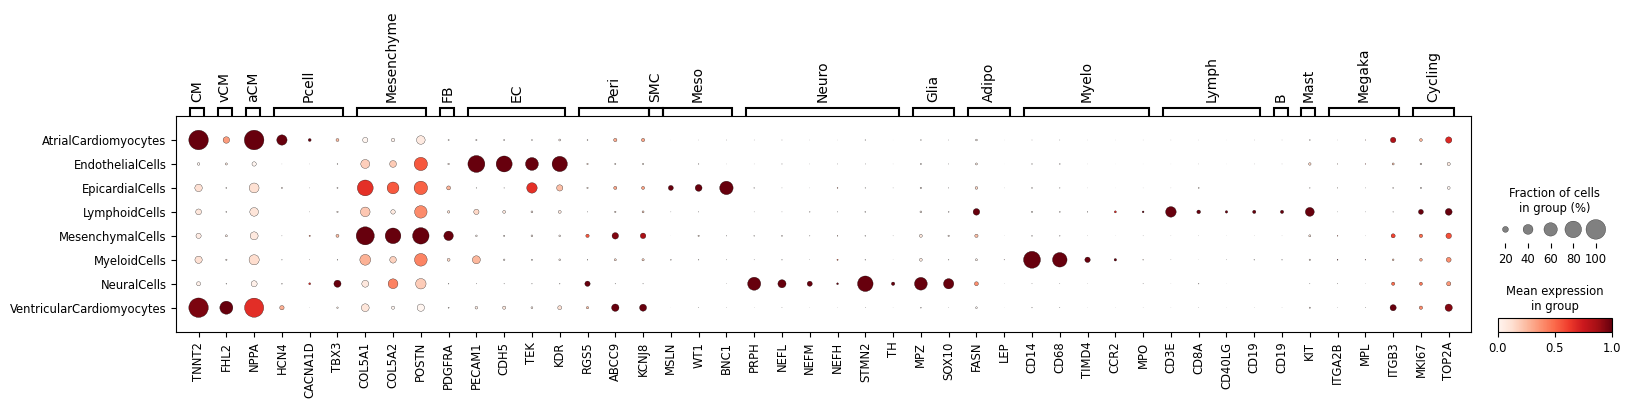

In [9]:
sdata_lognorm = sdata_sel.copy()
sc.pp.filter_genes(sdata_lognorm, min_cells=3)
sc.pp.normalize_total(sdata_lognorm, target_sum=1e4)
sc.pp.log1p(sdata_lognorm)

marker_genes_dict = {
    'CM': ['TTN', 'TNNT2','MYH6'],
    'vCM': ['MYH7', 'MYL2', 'FHL2'],
    'aCM': ['NPPA', 'MYL7', 'MYL4'],
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'Mesenchyme':['COL5A1','COL5A2','POSTN'], # markers in the Xenium5000 panel
    'FB': ['DCN', 'GCN', 'PDGFRA','COL1A1','COL1A2'],
    'EC': ['VWF', 'PECAM1', 'CDH5','RGCC', 'FABP5','TEK','KDR','LYVE1','CCL21'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Meso': ['MSLN', 'WT1', 'BNC1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3','PRPH', 'NEFL', 'NEFM', 'NEFH', 'STMN2', 'SST', 'SLC10A4', 'SLC18A3', 'TH', 'NPY'],
    'Glia':['MPZ','PLP1','SOX10'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','LYVE1','TIMD4','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG','CD19','SDC1','IGHG1','IGHA1'],
    'B': ['CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
    'Megaka':['ITGA2B','MPL','ITGB3', 'TUBB1', 'PPBP'],
    'Cycling':['MKI67','TOP2A'],
}

for k, v in marker_genes_dict.items():
    marker_genes_dict[k] = [x for x in v if x in sdata_lognorm.var_names]

sc.pl.dotplot(sdata_lognorm, 
              marker_genes_dict, 
              groupby='coarse_grain_tacco',
              dendrogram=False,
              standard_scale="var",
              color_map="Reds",
             # swap_axes=True
             )

In [10]:
sdata_sel.obs['coarse_grain_tacco'].value_counts()

coarse_grain_tacco
VentricularCardiomyocytes    174576
MesenchymalCells              86064
AtrialCardiomyocytes          50313
EndothelialCells              10891
EpicardialCells                4388
NeuralCells                    3626
MyeloidCells                   3126
LymphoidCells                   380
Name: count, dtype: int64

# DEGs

/rfs/project/rfs-iCNyzSAaucw/kk837/miniconda3/envs/TACCO_env/lib/python3.13/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 5001 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


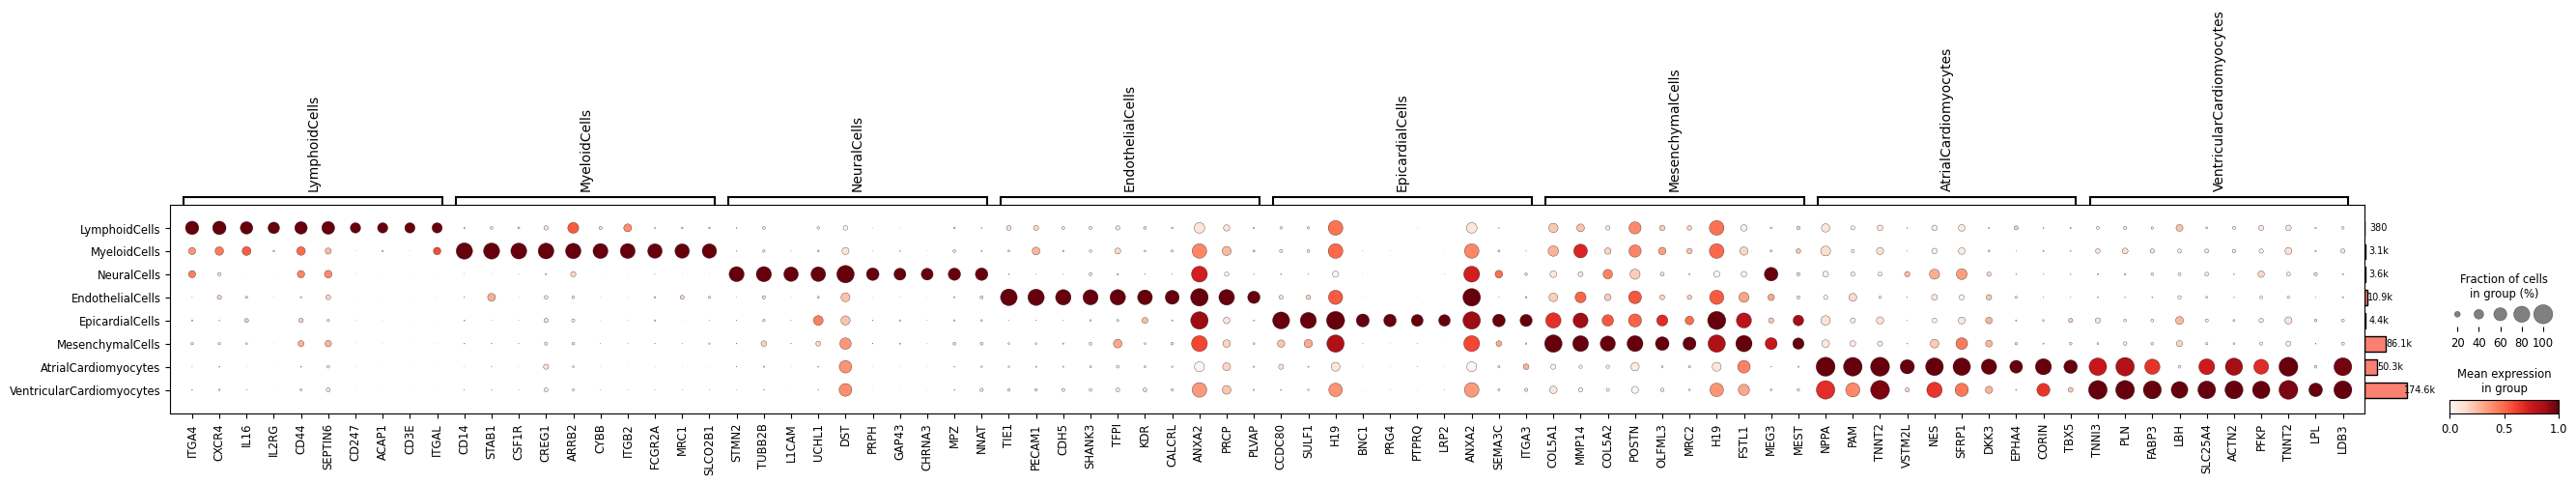

In [11]:
# DEG analysis
groupby = 'coarse_grain_tacco'

sdata_lognorm.uns['log1p']['base']=None
sc.tl.rank_genes_groups(sdata_lognorm,groupby=groupby)
sc.tl.dendrogram(sdata_lognorm, groupby=groupby)
dp=sc.pl.rank_genes_groups_dotplot(sdata_lognorm, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()

In [13]:
df = que.obsm['TACCO'].copy()
df.max(axis=1).reindex(sdata_sel.obs_names)

index
C194-HEA-0-FFPE-1_aejdbbej-1     0.904395
C194-HEA-0-FFPE-1_aejddfna-1     0.955318
C194-HEA-0-FFPE-1_aejfdefe-1     0.939991
C194-HEA-0-FFPE-1_aejfllbl-1     0.995178
C194-HEA-0-FFPE-1_aejfohee-1     0.943768
                                   ...   
Hst45-HEA-0-FFPE-1_oigbdbao-1    0.900546
Hst45-HEA-0-FFPE-1_oigbenna-1    0.832063
Hst45-HEA-0-FFPE-1_oigbmoed-1    0.972779
Hst45-HEA-0-FFPE-1_oigcbndd-1    0.989516
Hst45-HEA-0-FFPE-1_oigeiifh-1    0.979102
Length: 333364, dtype: float64

In [14]:
set(sdata_sel.obs[groupby])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'LymphoidCells',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes'}

# Cell composition scores per annotated cell types

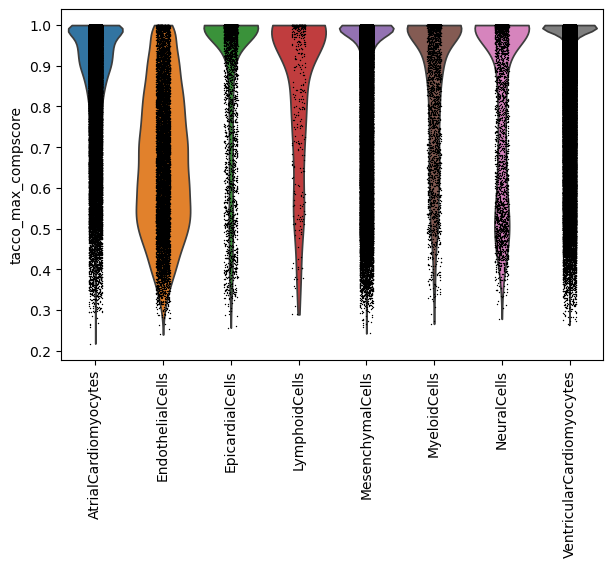

In [15]:
groupby = 'coarse_grain_tacco'

# add max composition score
df = que.obsm['TACCO'].copy()
sdata_sel.obs['tacco_max_compscore'] = df.max(axis=1).reindex(sdata_sel.obs_names)

ax = sc.pl.violin(sdata_sel, keys='tacco_max_compscore', groupby=groupby,
             rotation=90,show=False)
plt.show()

# Save

In [16]:
print(sdata_sel.X.data[:10])
sdata_sel.write(f'{data_object_dir}/TACCO/tacco-splitted_filtered_raw.h5ad')

[1. 3. 1. 5. 2. 1. 1. 2. 3. 2.]


In [17]:
f'{data_object_dir}/TACCO/tacco-splitted_filtered_raw.h5ad'

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/tacco-splitted_filtered_raw.h5ad'